# Plot Metrics From `results/`

This notebook reads CSV files with metrics
(`epoch`, `train_loss`, `test_loss`, `train_ppl`, `test_ppl`)
and builds quality-vs-epoch plots.

Main universal function: `plot_case(...)`.

In [15]:
from pathlib import Path
from typing import Optional, Sequence
import re

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
RESULTS_DIR = Path('results')

print('RESULTS_DIR =', RESULTS_DIR.resolve())

RESULTS_DIR = C:\Users\Marishka\Desktop\code\Neironki\Lab_4_Transformers\results


In [16]:
def find_result_files(
    results_dir: Path | str = RESULTS_DIR,
    include: Optional[Sequence[str]] = None,
    exclude: Optional[Sequence[str]] = None,
    regex: Optional[str] = None,
    sort_by: str = 'name'
) -> list[Path]:
    """Find metric CSV files by conditions."""
    results_dir = Path(results_dir)
    files = list(results_dir.glob('*.csv'))

    if include:
        files = [f for f in files if all(token in f.name for token in include)]

    if exclude:
        files = [f for f in files if all(token not in f.name for token in exclude)]

    if regex:
        pattern = re.compile(regex)
        files = [f for f in files if pattern.search(f.name)]

    if sort_by == 'mtime':
        files = sorted(files, key=lambda p: p.stat().st_mtime)
    else:
        files = sorted(files, key=lambda p: p.name)

    return files


def read_result_csv(path: Path | str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {'epoch', 'train_loss', 'test_loss', 'train_ppl', 'test_ppl'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'{path}: missing columns {sorted(missing)}')
    return df


def _annotate_points_non_overlapping(ax, x_values, series_map, fmt='{:.3f}', step_px=14):
    """Annotate multiple series and spread labels vertically to avoid overlap."""
    x_values = list(x_values)

    for idx, x in enumerate(x_values):
        points = []
        for name, values in series_map.items():
            points.append((name, float(values.iloc[idx])))

        points.sort(key=lambda item: item[1])
        n = len(points)
        offsets = [int((j - (n - 1) / 2) * step_px) for j in range(n)]

        for (name, y), dy in zip(points, offsets):
            ax.annotate(
                fmt.format(y),
                xy=(x, y),
                xytext=(0, dy),
                textcoords='offset points',
                fontsize=8,
                ha='center',
                va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.65)
            )


def plot_single(path: Path | str, figsize=(14, 5), annotate: bool = True):
    """Plot loss and PPL curves for one result CSV."""
    path = Path(path)
    df = read_result_csv(path)

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    axs[0].plot(df['epoch'], df['train_loss'], marker='o', label='train_loss')
    axs[0].plot(df['epoch'], df['test_loss'], marker='o', label='test_loss')
    axs[0].set_title(f'Loss: {path.stem}')
    axs[0].set_xlabel('epoch')
    axs[0].set_ylabel('loss')
    axs[0].legend()

    axs[1].plot(df['epoch'], df['train_ppl'], marker='o', label='train_ppl')
    axs[1].plot(df['epoch'], df['test_ppl'], marker='o', label='test_ppl')
    axs[1].set_title(f'PPL: {path.stem}')
    axs[1].set_xlabel('epoch')
    axs[1].set_ylabel('ppl')
    axs[1].legend()

    if annotate:
        _annotate_points_non_overlapping(
            axs[0],
            df['epoch'],
            {'train_loss': df['train_loss'], 'test_loss': df['test_loss']}
        )
        _annotate_points_non_overlapping(
            axs[1],
            df['epoch'],
            {'train_ppl': df['train_ppl'], 'test_ppl': df['test_ppl']}
        )

    plt.tight_layout()
    plt.show()
def plot_case(
    include: Optional[Sequence[str]] = None,
    exclude: Optional[Sequence[str]] = None,
    regex: Optional[str] = None,
    results_dir: Path | str = RESULTS_DIR,
    metric: str = 'test_loss',
    figsize=(14, 5),
    show_table: bool = True
):
    """Compare multiple experiments and plot test curves."""
    files = find_result_files(results_dir, include=include, exclude=exclude, regex=regex, sort_by='mtime')
    if not files:
        print('No files matched given filters.')
        return []

    if show_table:
        rows = []
        for f in files:
            df = read_result_csv(f)
            if ('loss' in metric) or ('ppl' in metric):
                best_row = df.loc[df[metric].idxmin()]
            else:
                best_row = df.loc[df[metric].idxmax()]

            best_ppl_row = df.loc[df['test_ppl'].idxmin()]
            rows.append({
                'file': f.name,
                'epochs': int(df['epoch'].max()),
                f'best_{metric}': float(best_row[metric]),
                'best_epoch': int(best_row['epoch']),
                'best_ppl': float(best_ppl_row['test_ppl']),
                'best_ppl_epoch': int(best_ppl_row['epoch'])
            })
        display(pd.DataFrame(rows))

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    for f in files:
        df = read_result_csv(f)
        axs[0].plot(df['epoch'], df['test_loss'], label=f.stem)
    axs[0].set_title('Test Loss by Epoch')
    axs[0].set_xlabel('epoch')
    axs[0].set_ylabel('test_loss')
    axs[0].legend(fontsize=8)

    for f in files:
        df = read_result_csv(f)
        axs[1].plot(df['epoch'], df['test_ppl'], label=f.stem)
    axs[1].set_title('Test PPL by Epoch')
    axs[1].set_xlabel('epoch')
    axs[1].set_ylabel('test_ppl')
    axs[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return files

In [17]:
# List all available CSV files
all_files = find_result_files()
for p in all_files:
    print(p.name)
print('Total files:', len(all_files))

0-hdim256_heads4_ffn2048_run_Transformer-d-MHA_head_count_en_fr_22-55_24-05-2026.csv
1-hdim256_heads8_ffn2048_run_Transformer_en_fr_19-50_24-05-2026.csv
2-hdim256_heads16_ffn2048_run_Transformer-d-MHA_head_count_en_fr_23-20_24-05-2026.csv
hdim256_heads8_ffn2048_run_Transformer-a-GeLU_en_fr_20-30_24-05-2026.csv
hdim256_heads8_ffn2048_run_Transformer-b-LN_pre_post_post_en_fr_21-01_24-05-2026.csv
hdim256_heads8_ffn2048_run_Transformer-b-LN_pre_post_pre_en_fr_21-39_24-05-2026.csv
hdim256_heads8_ffn2048_run_Transformer-c-neiron_count_2n_en_fr_22-08_24-05-2026.csv
hdim256_heads8_ffn2048_run_Transformer-c-neiron_count_4n_en_fr_22-30_24-05-2026.csv
Total files: 8


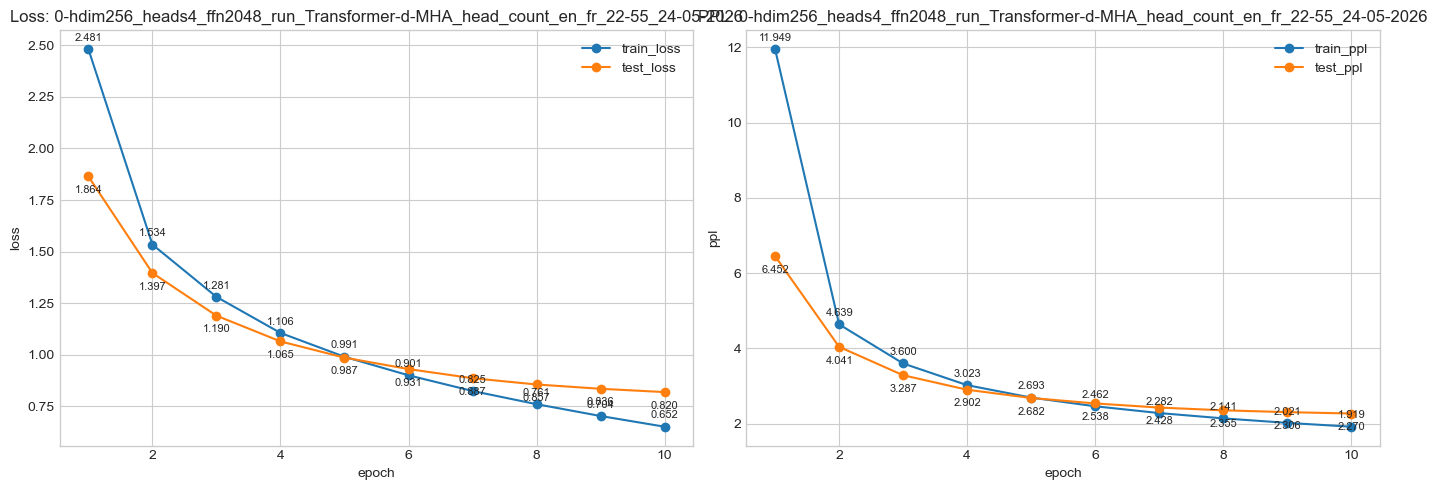

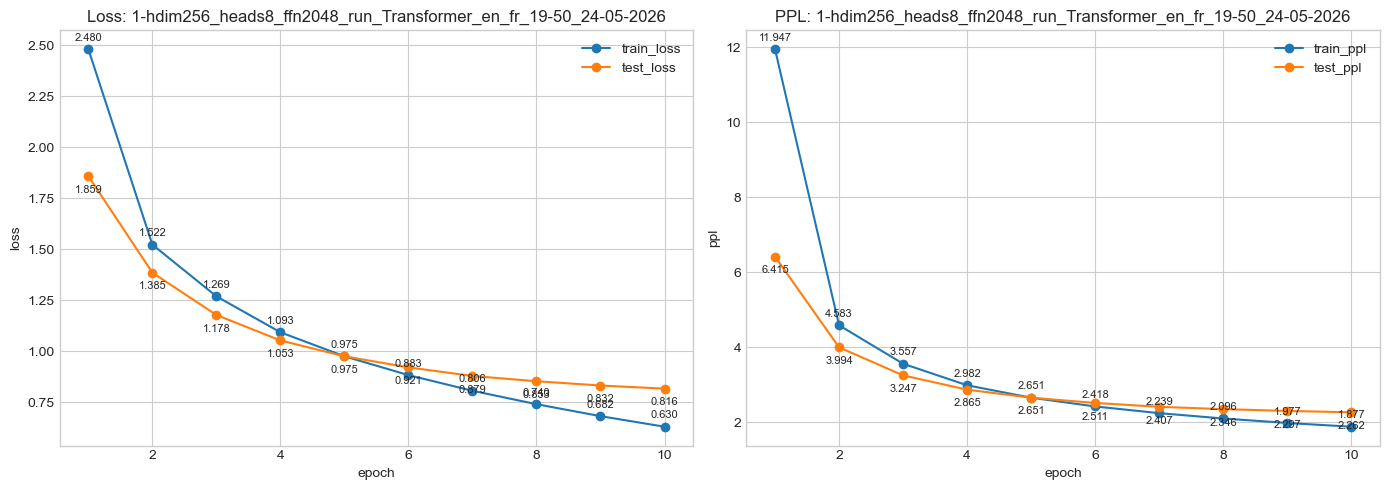

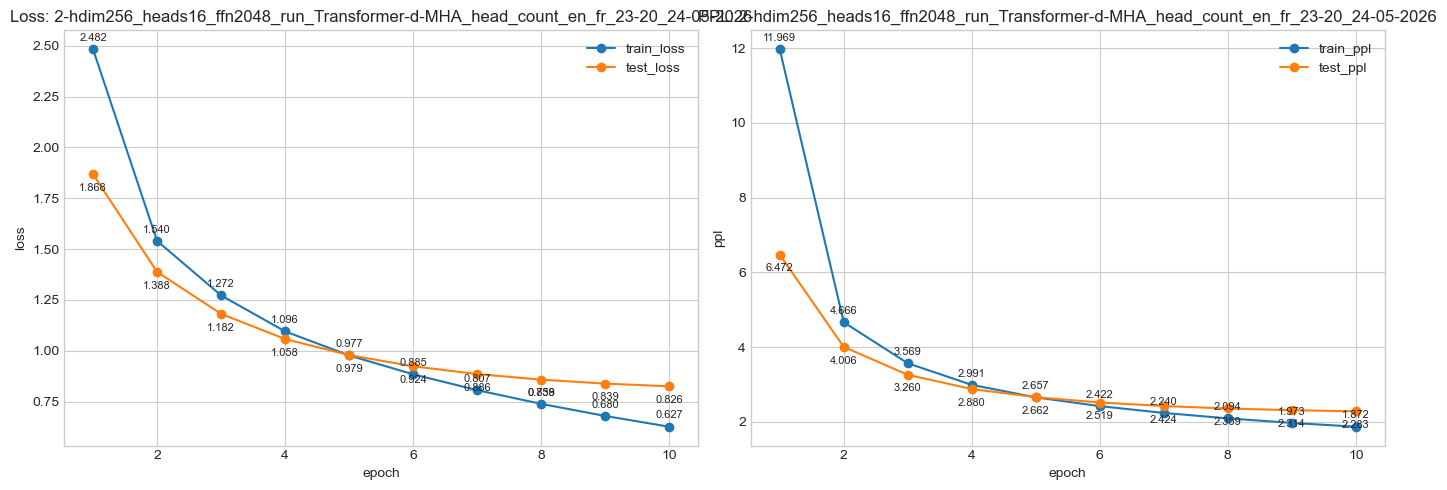

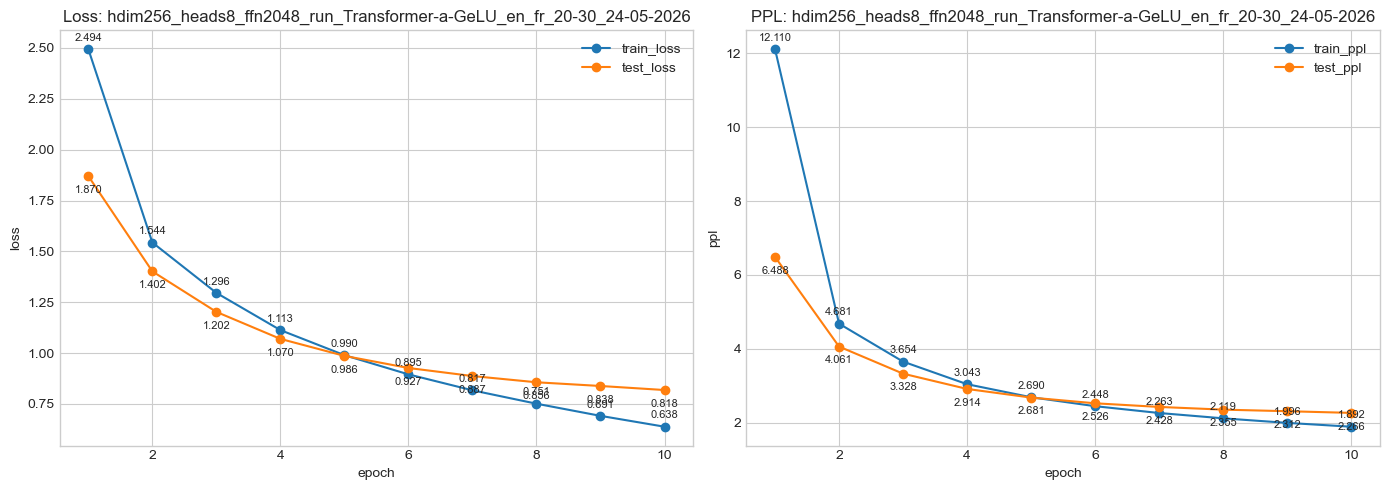

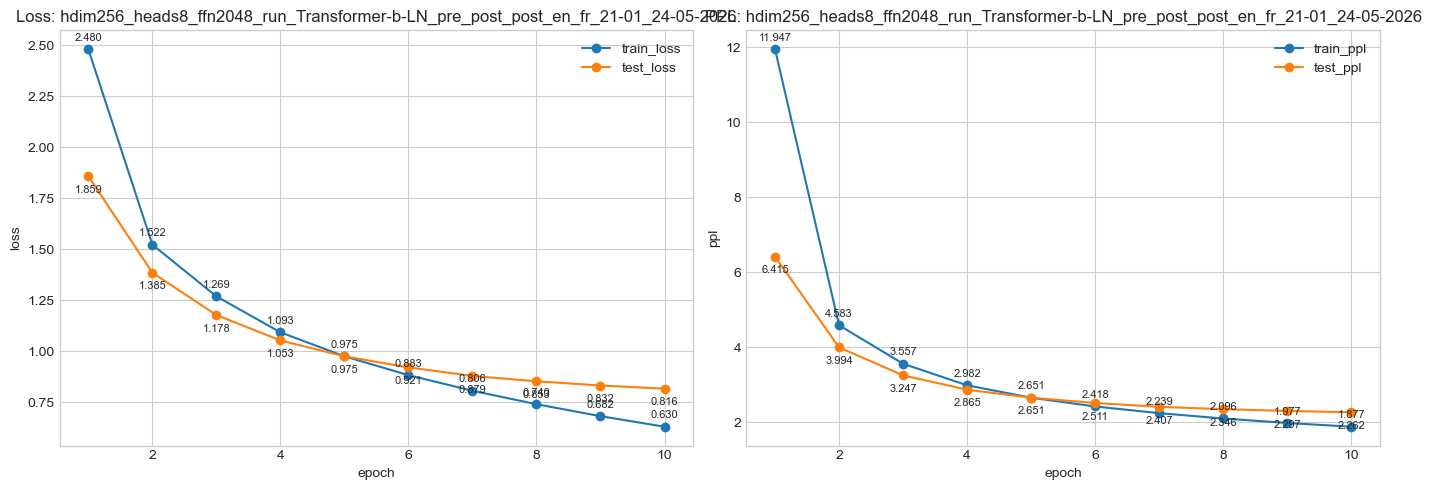

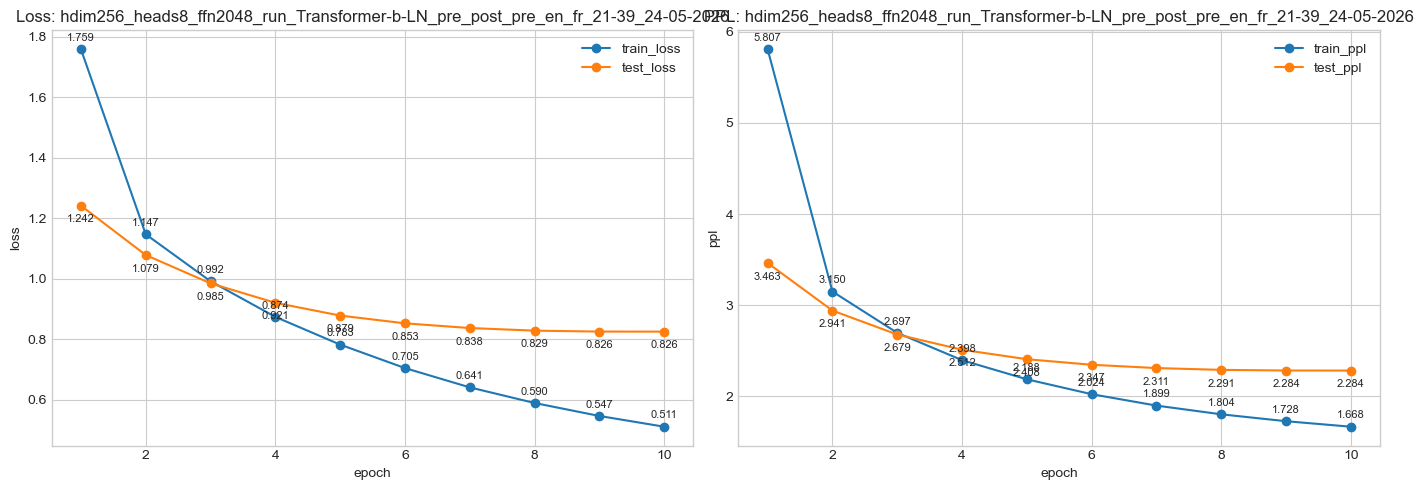

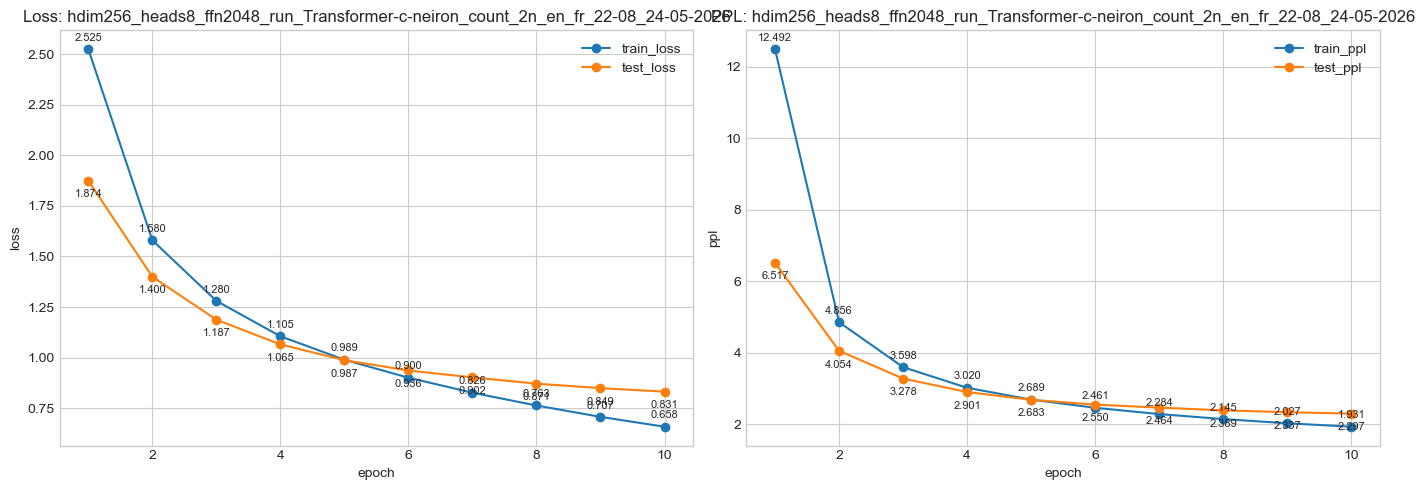

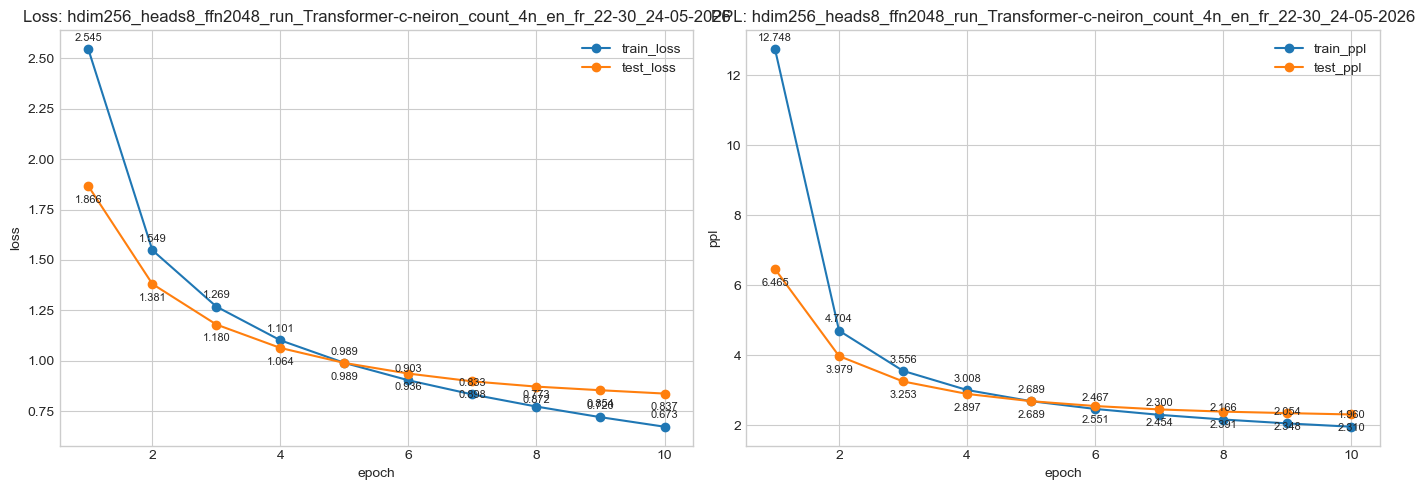

In [18]:
# Example 1: plot latest single result
for item in all_files:
    plot_single(item)

In [19]:
# Example 2: compare variant b files
# _ = plot_case(include=['Transformer-b'])

,file,epochs,best_test_loss,best_epoch,best_ppl,best_ppl_epoch
0,1-hdim256_heads8_ffn2048_run_Transformer_en_fr...,10,0.816329,10,2.262181,10
1,hdim256_heads8_ffn2048_run_Transformer-a-GeLU_...,10,0.818204,10,2.266426,10
2,hdim256_heads8_ffn2048_run_Transformer-b-LN_pr...,10,0.816329,10,2.262181,10
3,hdim256_heads8_ffn2048_run_Transformer-b-LN_pr...,10,0.825719,10,2.283523,10
4,hdim256_heads8_ffn2048_run_Transformer-c-neiro...,10,0.831399,10,2.296529,10
5,hdim256_heads8_ffn2048_run_Transformer-c-neiro...,10,0.837197,10,2.309884,10
6,0-hdim256_heads4_ffn2048_run_Transformer-d-MHA...,10,0.819705,10,2.269830,10
7,2-hdim256_heads16_ffn2048_run_Transformer-d-MH...,10,0.825578,10,2.283200,10


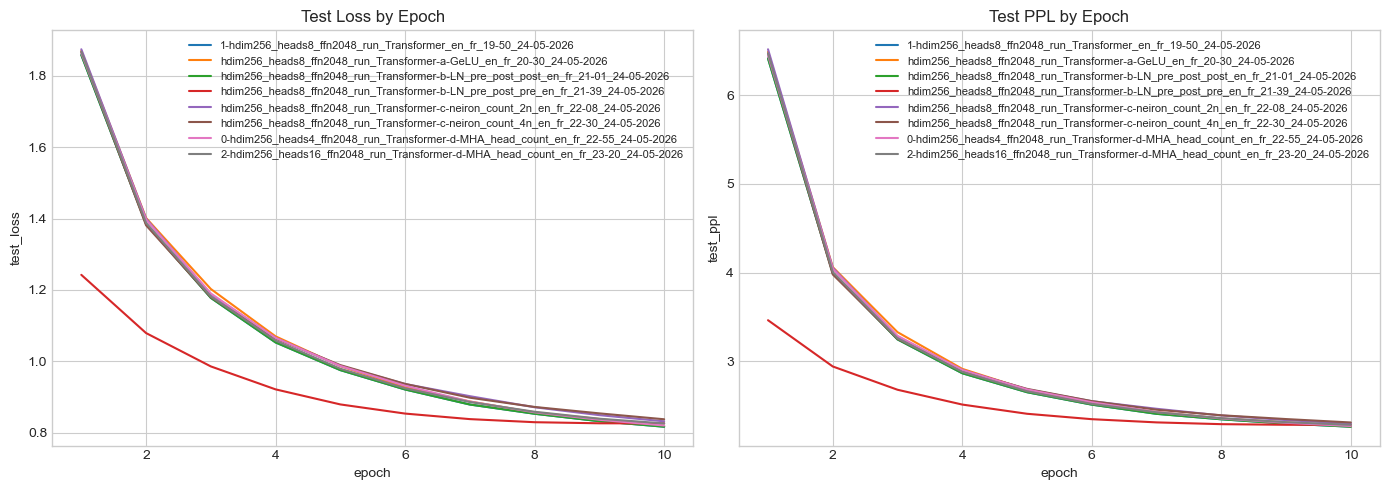

In [20]:
# Example 3: universal run (change include tokens as needed)
_ = plot_case(include=['Transformer'])